In [11]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [12]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,55285_00000,0,0.458971,least_confidence,1,1141.736265
1,1,55285_00000,1,0.753181,least_confidence,1,1141.736265
2,2,55285_00000,2,0.752538,least_confidence,1,1141.736265
3,3,55285_00000,3,0.751263,least_confidence,1,1141.736265
4,4,55285_00000,4,0.509333,least_confidence,1,1141.736265
...,...,...,...,...,...,...,...
31970,31970,55285_00024,1274,0.965353,random,5,1148.707853
31971,31971,55285_00024,1275,0.980363,random,5,1148.707853
31972,31972,55285_00024,1276,0.975144,random,5,1148.707853
31973,31973,55285_00024,1277,0.980025,random,5,1148.707853


In [13]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
25580,25580,55285_00020,0,0.444686,random,1,1139.052934
25581,25581,55285_00020,1,0.566410,random,1,1139.052934
25582,25582,55285_00020,2,0.566410,random,1,1139.052934
25583,25583,55285_00020,3,0.460733,random,1,1139.052934
25584,25584,55285_00020,4,0.452962,random,1,1139.052934
...,...,...,...,...,...,...,...
31970,31970,55285_00024,1274,0.965353,random,5,1148.707853
31971,31971,55285_00024,1275,0.980363,random,5,1148.707853
31972,31972,55285_00024,1276,0.975144,random,5,1148.707853
31973,31973,55285_00024,1277,0.980025,random,5,1148.707853


In [14]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_29801/2952143151.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


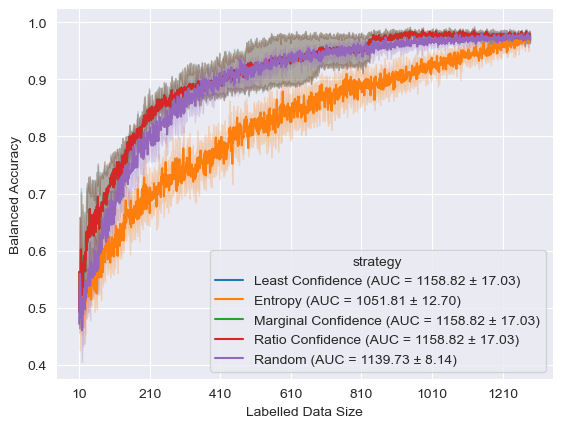

In [15]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)